# AI-Powered Software Engineering Assistant
**Capstone Project — IIIT Hyderabad PG**

**Backbone:** `Salesforce/codegen-350M-multi` · LoRA · RAG · Agentic Self-Correction

---
**Runtime:** GPU (T4 or better) · **Runtime → Change runtime type → T4 GPU**

Run cells top-to-bottom. Each section is a self-contained phase.

## Phase 1 — Environment Setup

In [ ]:
import subprocess, sys

# Check GPU
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'No GPU — go to Runtime > Change runtime type > T4 GPU')

Sat Jul  4 11:36:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%capture
!pip install -q \
    transformers==4.51.3 \
    peft==0.15.2 \
    accelerate==1.7.0 \
    datasets==3.6.0 \
    sentence-transformers==4.1.0 \
    faiss-gpu \
    evaluate==0.4.3 \
    sacrebleu==2.5.1 \
    bert-score==0.3.13 \
    gradio==5.31.0 \
    code-bert-score

print('All packages installed.')

In [ ]:
import os, json, re, ast, sys, time, subprocess, tempfile, textwrap
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import torch
import numpy as np

# Project directories
ROOT = Path('/content/capstone')
for d in ['data/mbpp', 'data/humaneval', 'data/codocbench', 'data/repo_corpus',
          'models/baseline', 'models/lora_finetuned',
          'retrieval/vector_store', 'evaluation/results']:
    (ROOT / d).mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## Phase 1b — Download Datasets

In [ ]:
import urllib.request, gzip

# ── MBPP sanitized ──────────────────────────────────────────
mbpp_path = ROOT / 'data/mbpp/sanitized-mbpp.json'
if not mbpp_path.exists():
    url = 'https://huggingface.co/datasets/Muennighoff/mbpp/resolve/main/data/sanitized-mbpp.json'
    urllib.request.urlretrieve(url, mbpp_path)
with open(mbpp_path) as f:
    mbpp = json.load(f)
print(f'MBPP: {len(mbpp)} problems')

# ── HumanEval ───────────────────────────────────────────────
he_path = ROOT / 'data/humaneval/humaneval_test.json'
if not he_path.exists():
    url = 'https://github.com/openai/human-eval/raw/master/data/HumanEval.jsonl.gz'
    gz_path = ROOT / 'data/humaneval/HumanEval.jsonl.gz'
    urllib.request.urlretrieve(url, gz_path)
    problems = []
    with gzip.open(gz_path, 'rt') as f:
        for line in f:
            p = json.loads(line)
            problems.append({'task_id': p['task_id'], 'prompt': p['prompt'],
                             'canonical_solution': p['canonical_solution'],
                             'test': p['test'], 'entry_point': p['entry_point']})
    with open(he_path, 'w') as f:
        json.dump(problems, f)
with open(he_path) as f:
    humaneval = json.load(f)
print(f'HumanEval: {len(humaneval)} problems')

# ── Synthetic CoDocBench from MBPP ──────────────────────────
codoc_path = ROOT / 'data/codocbench/codocbench_synthetic.json'
if not codoc_path.exists():
    pairs = []
    for p in mbpp:
        code = p.get('code', '')
        doc = p.get('prompt', '')
        if code and doc:
            pairs.append({'code': code, 'docstring': doc,
                          'source': 'mbpp', 'task_id': p.get('task_id', '')})
    with open(codoc_path, 'w') as f:
        json.dump(pairs, f)
print(f'CoDocBench synthetic: {len(pairs) if not codoc_path.stat().st_size == 0 else "already built"} pairs')

MBPP: 427 problems
HumanEval: 164 problems
CoDocBench synthetic: 427 pairs


In [ ]:
# Clone repositories for RAG corpus
repos = [
    ('fastapi', 'https://github.com/tiangolo/fastapi.git'),
    ('httpx',   'https://github.com/encode/httpx.git'),
    ('rich',    'https://github.com/Textualize/rich.git'),
    ('pydantic','https://github.com/pydantic/pydantic.git'),
]
for name, url in repos:
    dest = ROOT / 'data/repo_corpus' / name
    if not dest.exists():
        print(f'Cloning {name}...')
        subprocess.run(['git', 'clone', '--depth=1', url, str(dest)],
                       capture_output=True)
    py_count = len(list(dest.rglob('*.py')))
    print(f'  {name}: {py_count} Python files')

Cloning fastapi...
  fastapi: 1129 Python files
Cloning httpx...
  httpx: 60 Python files
Cloning rich...
  rich: 213 Python files
Cloning pydantic...
  pydantic: 405 Python files


## Phase 2 — Load CodeGen Model (Baseline)

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, StoppingCriteria, StoppingCriteriaList

MODEL_ID = 'Salesforce/codegen-350M-multi'
CACHE_DIR = str(ROOT / 'models/baseline')

print(f'Loading {MODEL_ID} on {DEVICE}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, cache_dir=CACHE_DIR)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    cache_dir=CACHE_DIR,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
    low_cpu_mem_usage=True,
)
base_model = base_model.to(DEVICE)
base_model.eval()
print(f'Model loaded: {sum(p.numel() for p in base_model.parameters())/1e6:.1f}M params')

Loading Salesforce/codegen-350M-multi on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/240 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/797M [00:00<?, ?B/s]

Some weights of the model checkpoint at Salesforce/codegen-350M-multi were not used when initializing CodeGenForCausalLM: ['transformer.h.0.attn.causal_mask', 'transformer.h.1.attn.causal_mask', 'transformer.h.10.attn.causal_mask', 'transformer.h.11.attn.causal_mask', 'transformer.h.12.attn.causal_mask', 'transformer.h.13.attn.causal_mask', 'transformer.h.14.attn.causal_mask', 'transformer.h.15.attn.causal_mask', 'transformer.h.16.attn.causal_mask', 'transformer.h.17.attn.causal_mask', 'transformer.h.18.attn.causal_mask', 'transformer.h.19.attn.causal_mask', 'transformer.h.2.attn.causal_mask', 'transformer.h.3.attn.causal_mask', 'transformer.h.4.attn.causal_mask', 'transformer.h.5.attn.causal_mask', 'transformer.h.6.attn.causal_mask', 'transformer.h.7.attn.causal_mask', 'transformer.h.8.attn.causal_mask', 'transformer.h.9.attn.causal_mask']
- This IS expected if you are initializing CodeGenForCausalLM from the checkpoint of a model trained on another task or with another architecture (

Model loaded: 356.7M params


In [ ]:
# ── Stopping criteria: stop at next function/class definition ──
class StopAtNewDef(StoppingCriteria):
    def __init__(self, tokenizer):
        self.stop_ids = [
            tokenizer.encode(s, add_special_tokens=False)
            for s in ['\nclass ', '\ndef ', '\n#', '\nif __name__']
        ]
    def __call__(self, input_ids, scores, **kwargs):
        for stop in self.stop_ids:
            if len(stop) and input_ids.shape[1] >= len(stop):
                if input_ids[0, -len(stop):].tolist() == stop:
                    return True
        return False

def generate_code(model, prompt, max_new_tokens=256, temperature=0.8,
                  top_p=0.95, num_samples=1, stop=True):
    inputs = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    in_len = inputs['input_ids'].shape[1]
    sc = StoppingCriteriaList([StopAtNewDef(tokenizer)]) if stop else None
    do_sample = temperature > 0
    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        num_return_sequences=num_samples,
        pad_token_id=tokenizer.eos_token_id,
        stopping_criteria=sc,
    )
    if do_sample:
        gen_kwargs['temperature'] = temperature
        gen_kwargs['top_p'] = top_p
    with torch.no_grad():
        out = model.generate(**inputs, **gen_kwargs)
    return [tokenizer.decode(seq[in_len:], skip_special_tokens=True) for seq in out]

# Quick baseline test
prompt = '"""\nWrite a Python function to find the sum of all elements in a list.\n"""\ndef '
result = generate_code(base_model, prompt, max_new_tokens=128)[0]
print('=== Baseline output ===')
print(prompt + result)

=== Baseline output ===
"""
Write a Python function to find the sum of all elements in a list.
"""
def ida_list_sum(lst):
    sum = 0
    for val in lst:
        sum = sum + val
    return sum

print ida_list_sum([1,2,3,4,5,6])



## Phase 2b — Baseline Motivation Analysis

Run this **before LoRA fine-tuning** to measure baseline gaps (pass@1, BLEU, BERTScore) and show why fine-tuning is needed.

Generating baseline outputs for 30 problems...
  [30/30]
Done.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]


=== BASELINE PERFORMANCE — Why Fine-Tuning is Needed ===


,Metric,Baseline,Target (after LoRA)
0,pass@1,0.00%,>40%
1,BLEU,0.0345,>0.25
2,BERTScore F1,0.7824,>0.85
3,Missing return,2/30,0
4,Missing def,0/30,0


,Error type,Count
0,syntax,21
1,assertion,0
2,runtime,9
3,timeout,0


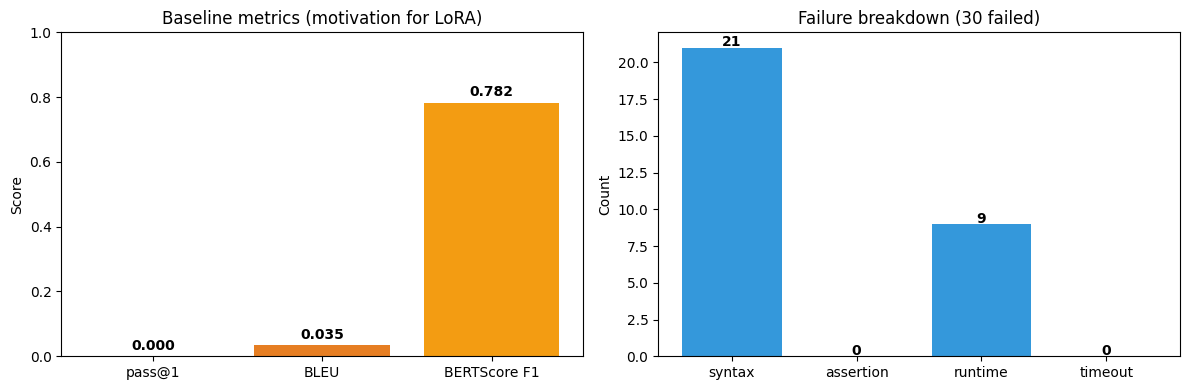

Chart saved → /content/capstone/evaluation/results/baseline_motivation.png

→ Low pass@1 and high assertion errors motivate Phase 3 (LoRA fine-tuning).


In [ ]:
# ── Sandbox helper (needed here; also redefined in Phase 6) ──
@dataclass
class ExecResult:
    passed: bool
    stdout: str = ''
    stderr: str = ''
    error_type: str = ''

def execute_with_tests(code, test_list, timeout=10):
    test_block = '\n'.join(test_list)
    full_code = f'{code}\n\n# --- tests ---\n{test_block}\n'
    with tempfile.NamedTemporaryFile(suffix='.py', mode='w', delete=False) as f:
        f.write(full_code)
        tmp = f.name
    try:
        r = subprocess.run([sys.executable, tmp], capture_output=True,
                           text=True, timeout=timeout)
        if r.returncode == 0:
            return ExecResult(True, r.stdout, '', 'pass')
        err = r.stderr
        err_type = 'runtime'
        if 'SyntaxError' in err:
            err_type = 'syntax'
        elif 'AssertionError' in err:
            err_type = 'assertion'
        return ExecResult(False, r.stdout, err, err_type)
    except subprocess.TimeoutExpired:
        return ExecResult(False, '', 'Timeout', 'timeout')
    finally:
        Path(tmp).unlink(missing_ok=True)

# ── Baseline evaluation on a small held-out slice ───────────
import sacrebleu
from bert_score import score as bert_score_fn
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

QUICK_N = 30
problems_eval = mbpp[:QUICK_N]
prompts_eval  = [f'"""\n{p["prompt"]}\n"""\ndef ' for p in problems_eval]
refs_eval     = [p['code'] for p in problems_eval]
tests_eval    = [p['test_list'] for p in problems_eval]

print(f'Generating baseline outputs for {QUICK_N} problems...')
baseline_preds = []
for i, prompt in enumerate(prompts_eval):
    out = generate_code(base_model, prompt, max_new_tokens=256)[0]
    baseline_preds.append(prompt + out)
    print(f'  [{i+1}/{QUICK_N}]', end='\r')
print('\nDone.')

# pass@1 + error breakdown
passed = 0
error_counts = {'syntax': 0, 'assertion': 0, 'runtime': 0, 'timeout': 0}
for pred, tests in zip(baseline_preds, tests_eval):
    r = execute_with_tests(pred, tests)
    if r.passed:
        passed += 1
    elif r.error_type in error_counts:
        error_counts[r.error_type] += 1

pass_at_1 = passed / QUICK_N
bleu = sacrebleu.corpus_bleu(baseline_preds, [refs_eval]).score / 100.0
_, _, F = bert_score_fn(baseline_preds, refs_eval,
                         model_type='distilbert-base-uncased',
                         device=DEVICE, verbose=False)
bertscore_f1 = F.mean().item()
incomplete = sum(1 for p in baseline_preds if 'return' not in p)
no_def = sum(1 for p in baseline_preds if 'def ' not in p)

# ── Table 1: metrics ──────────────────────────────────────────
metrics_df = pd.DataFrame({
    'Metric': ['pass@1', 'BLEU', 'BERTScore F1', 'Missing return', 'Missing def'],
    'Baseline': [f'{pass_at_1:.2%}', f'{bleu:.4f}', f'{bertscore_f1:.4f}',
                 f'{incomplete}/{QUICK_N}', f'{no_def}/{QUICK_N}'],
    'Target (after LoRA)': ['>40%', '>0.25', '>0.85', '0', '0'],
})
print('\n=== BASELINE PERFORMANCE — Why Fine-Tuning is Needed ===')
display(metrics_df)

# ── Table 2: error breakdown ────────────────────────────────
error_df = pd.DataFrame({
    'Error type': list(error_counts.keys()),
    'Count': list(error_counts.values()),
})
display(error_df)

# ── Chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metric_names = ['pass@1', 'BLEU', 'BERTScore F1']
metric_values = [pass_at_1, bleu, bertscore_f1]
axes[0].bar(metric_names, metric_values, color=['#e74c3c', '#e67e22', '#f39c12'])
axes[0].set_ylim(0, 1)
axes[0].set_title('Baseline metrics (motivation for LoRA)')
axes[0].set_ylabel('Score')
for i, v in enumerate(metric_values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(list(error_counts.keys()), list(error_counts.values()), color='#3498db')
axes[1].set_title(f'Failure breakdown ({QUICK_N - passed} failed)')
axes[1].set_ylabel('Count')
for i, v in enumerate(error_counts.values()):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
chart_path = ROOT / 'evaluation/results/baseline_motivation.png'
plt.savefig(chart_path, dpi=150)
plt.show()
print(f'Chart saved → {chart_path}')
print('\n→ Low pass@1 and high assertion errors motivate Phase 3 (LoRA fine-tuning).')

## Phase 3 — LoRA Fine-Tuning

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from peft import LoraConfig, TaskType, get_peft_model

# ── Dataset ─────────────────────────────────────────────────
class MBPPDataset(Dataset):
    def __init__(self, problems, tokenizer, max_length=384):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.texts = []
        for p in problems:
            prompt = p.get('prompt', p.get('text', ''))
            code = p.get('code', '')
            if prompt and code:
                self.texts.append(f'\'\'\'\n{prompt}\n\'\'\'\n{code}\n')

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, max_length=self.max_length,
            padding='max_length', return_tensors='pt'
        )
        ids = enc['input_ids'].squeeze(0)
        return {'input_ids': ids, 'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': ids.clone()}

# ── LoRA config ─────────────────────────────────────────────
lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16, lora_alpha=32,
    target_modules=['qkv_proj', 'out_proj'],
    lora_dropout=0.05, bias='none',
    inference_mode=False,
)

# Re-load fresh base model for LoRA (keeps base_model clean for baseline eval)
from copy import deepcopy
lora_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, cache_dir=CACHE_DIR,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
    low_cpu_mem_usage=True,
)
lora_model = get_peft_model(lora_model, lora_cfg)
lora_model.print_trainable_parameters()

Some weights of the model checkpoint at Salesforce/codegen-350M-multi were not used when initializing CodeGenForCausalLM: ['transformer.h.0.attn.causal_mask', 'transformer.h.1.attn.causal_mask', 'transformer.h.10.attn.causal_mask', 'transformer.h.11.attn.causal_mask', 'transformer.h.12.attn.causal_mask', 'transformer.h.13.attn.causal_mask', 'transformer.h.14.attn.causal_mask', 'transformer.h.15.attn.causal_mask', 'transformer.h.16.attn.causal_mask', 'transformer.h.17.attn.causal_mask', 'transformer.h.18.attn.causal_mask', 'transformer.h.19.attn.causal_mask', 'transformer.h.2.attn.causal_mask', 'transformer.h.3.attn.causal_mask', 'transformer.h.4.attn.causal_mask', 'transformer.h.5.attn.causal_mask', 'transformer.h.6.attn.causal_mask', 'transformer.h.7.attn.causal_mask', 'transformer.h.8.attn.causal_mask', 'transformer.h.9.attn.causal_mask']
- This IS expected if you are initializing CodeGenForCausalLM from the checkpoint of a model trained on another task or with another architecture (

trainable params: 1,966,080 || all params: 358,678,528 || trainable%: 0.5481


In [ ]:
# ── Training loop ────────────────────────────────────────────
EPOCHS = 3
BATCH = 4
LR = 2e-4
MAX_SAMPLES = 374   # use 374 / 427 for training, rest for eval
MAX_STEPS = 300     # hard cap — about 8-12 min on T4

train_data = MBPPDataset(mbpp[:MAX_SAMPLES], tokenizer)
print(f'Training on {len(train_data)} samples')

def collate(batch):
    return {
        'input_ids':      torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'labels':         torch.stack([b['labels'] for b in batch]),
    }

loader = DataLoader(train_data, batch_size=BATCH, shuffle=True,
                    collate_fn=collate, drop_last=True)
optimizer = AdamW(lora_model.parameters(), lr=LR, weight_decay=0.01)
total_steps = min(MAX_STEPS, (len(loader)) * EPOCHS)
scheduler = get_cosine_schedule_with_warmup(optimizer,
                num_warmup_steps=max(1, int(total_steps * 0.05)),
                num_training_steps=total_steps)

lora_model = lora_model.to(DEVICE)
lora_model.train()

global_step = 0
for epoch in range(EPOCHS):
    if global_step >= MAX_STEPS:
        break
    epoch_loss = 0.0
    for step, batch in enumerate(loader):
        if global_step >= MAX_STEPS:
            break
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = lora_model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lora_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()
        global_step += 1
        if global_step % 20 == 0:
            print(f'  epoch={epoch+1} step={global_step} '
                  f'loss={epoch_loss/step:.4f} lr={scheduler.get_last_lr()[0]:.2e}')

# Save adapter
LORA_DIR = str(ROOT / 'models/lora_finetuned')
lora_model.save_pretrained(LORA_DIR)
tokenizer.save_pretrained(LORA_DIR)
print(f'\nLoRA adapter saved → {LORA_DIR}')

# Put in eval mode
lora_model.eval()

Training on 374 samples
  epoch=1 step=20 loss=10.5002 lr=2.00e-04
  epoch=1 step=40 loss=5.3069 lr=1.95e-04
  epoch=1 step=60 loss=3.5964 lr=1.85e-04
  epoch=1 step=80 loss=2.7510 lr=1.70e-04
  epoch=2 step=100 loss=0.2522 lr=1.52e-04
  epoch=2 step=120 loss=0.2348 lr=1.30e-04
  epoch=2 step=140 loss=0.2325 lr=1.07e-04
  epoch=2 step=160 loss=0.2377 lr=8.35e-05
  epoch=2 step=180 loss=0.2397 lr=6.09e-05
  epoch=3 step=200 loss=0.2421 lr=4.05e-05
  epoch=3 step=220 loss=0.2308 lr=2.33e-05
  epoch=3 step=240 loss=0.2313 lr=1.04e-05
  epoch=3 step=260 loss=0.2261 lr=2.51e-06


config.json: 0.00B [00:00, ?B/s]


LoRA adapter saved → /content/capstone/models/lora_finetuned


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): CodeGenForCausalLM(
      (transformer): CodeGenModel(
        (wte): Embedding(51200, 1024)
        (drop): Dropout(p=0.0, inplace=False)
        (h): ModuleList(
          (0-19): 20 x CodeGenBlock(
            (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (attn): CodeGenAttention(
              (attn_dropout): Dropout(p=0.0, inplace=False)
              (resid_dropout): Dropout(p=0.0, inplace=False)
              (qkv_proj): lora.Linear(
                (base_layer): Linear(in_features=1024, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1024, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3072, bias=Fal

In [ ]:
# Quick LoRA vs Baseline comparison
test_prompt = '"""\nWrite a Python function to check if a number is prime.\n"""\ndef '

print('=== BASELINE ===')
print(test_prompt + generate_code(base_model, test_prompt)[0])

print('\n=== LORA ===')
print(test_prompt + generate_code(lora_model, test_prompt)[0])

=== BASELINE ===
"""
Write a Python function to check if a number is prime.
"""
def irt_is_prime(n):
    if n % 2 == 0:
        return False
    else:
        return True

for i in xrange(1, 10**5):
    if i % 2 == 0:
        continue
    if irt_is_prime(i):
        print(i, "is prime")


=== LORA ===
"""
Write a Python function to check if a number is prime.
"""
def ix_prime(num):
    for n in range(2,num+1):
        if num % n == 0:
            return False
    return True



## Phase 4 — Documentation Generation

In [ ]:
from bert_score import score as bert_score_fn
import sacrebleu

def compute_bleu(preds, refs):
    result = sacrebleu.corpus_bleu(preds, [refs])
    return result.score / 100.0

def compute_bertscore(preds, refs, model_type='distilbert-base-uncased'):
    P, R, F = bert_score_fn(preds, refs, model_type=model_type,
                             device=DEVICE, verbose=False)
    return {'precision': P.mean().item(), 'recall': R.mean().item(), 'f1': F.mean().item()}

# Load CoDocBench
with open(ROOT / 'data/codocbench/codocbench_synthetic.json') as f:
    codoc = json.load(f)

N_DOC = 50
doc_preds, doc_refs = [], []

print(f'Generating docstrings for {N_DOC} code snippets...')
for i, pair in enumerate(codoc[:N_DOC]):
    code = pair['code']
    prompt = (
        '# Write a detailed Python docstring for the following function:\n'
        f'{code}\n'
        '# Docstring:\n"""'
    )
    raw = generate_code(base_model, prompt, max_new_tokens=128,
                        temperature=0.4, stop=False)[0]
    end = raw.find('"""')
    generated = raw[:end].strip() if end != -1 else raw.strip()
    doc_preds.append(generated)
    doc_refs.append(pair['docstring'])
    if (i+1) % 10 == 0:
        print(f'  {i+1}/{N_DOC}')

bleu = compute_bleu(doc_preds, doc_refs)
bs = compute_bertscore(doc_preds, doc_refs)

doc_results = {'bleu': bleu, 'bertscore_f1': bs['f1']}
print('\n=== Documentation Generation Results ===')
print(f"  BLEU:           {bleu:.4f}")
print(f"  BERTScore F1:   {bs['f1']:.4f}")

with open(ROOT / 'evaluation/results/doc_gen.json', 'w') as f:
    json.dump({'metrics': doc_results, 'samples': [
        {'code': codoc[i]['code'][:150], 'generated': doc_preds[i], 'reference': doc_refs[i]}
        for i in range(5)
    ]}, f, indent=2)

Generating docstrings for 50 code snippets...
  10/50
  20/50
  30/50
  40/50
  50/50

=== Documentation Generation Results ===
  BLEU:           0.0214
  BERTScore F1:   0.7423


## Phase 5 — Build FAISS RAG Index

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss

# ── Parse repos into function-level chunks ───────────────────
def extract_functions(source, file_path):
    chunks = []
    try:
        tree = ast.parse(source)
    except SyntaxError:
        return chunks
    lines = source.splitlines()
    for node in ast.walk(tree):
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
            start = node.lineno - 1
            end = getattr(node, 'end_lineno', start + 20)
            code = '\n'.join(lines[start:end])
            if 10 <= len(code) <= 2000:
                chunks.append({'code': code, 'name': node.name,
                                'file': file_path, 'lineno': node.lineno})
    return chunks

corpus_dir = ROOT / 'data/repo_corpus'
all_chunks = []
for repo_dir in sorted(corpus_dir.iterdir()):
    if not repo_dir.is_dir(): continue
    repo_chunks = 0
    for py_file in list(repo_dir.rglob('*.py'))[:200]:
        try:
            src = py_file.read_text(errors='ignore')
        except Exception:
            continue
        for c in extract_functions(src, str(py_file.relative_to(ROOT))):
            all_chunks.append(c)
            repo_chunks += 1
    print(f'  {repo_dir.name}: {repo_chunks} chunks')
print(f'Total: {len(all_chunks)} function chunks')

  fastapi: 1874 chunks
  httpx: 1115 chunks
  pydantic: 6125 chunks
  rich: 1740 chunks
Total: 10854 function chunks


In [ ]:
# ── Embed with sentence-transformers (80 MB, fast on GPU) ────
print('Loading sentence-transformers/all-MiniLM-L6-v2...')
st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2',
                                device=DEVICE)

texts = [c['code'] for c in all_chunks]
print(f'Embedding {len(texts)} chunks...')
embeddings = st_model.encode(
    texts, batch_size=256, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True
).astype(np.float32)
print(f'Embeddings shape: {embeddings.shape}')

# ── Build FAISS index ────────────────────────────────────────
dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings)
print(f'FAISS index: {index.ntotal} vectors, dim={dim}')

# Save
INDEX_DIR = ROOT / 'retrieval/vector_store'
faiss.write_index(index, str(INDEX_DIR / 'repo.index'))
with open(INDEX_DIR / 'chunks.json', 'w') as f:
    json.dump(all_chunks, f)
np.save(INDEX_DIR / 'embeddings.npy', embeddings)
print(f'Index saved → {INDEX_DIR}')

Loading sentence-transformers/all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 10854 chunks...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

Embeddings shape: (10854, 384)
FAISS index: 10854 vectors, dim=384
Index saved → /content/capstone/retrieval/vector_store


In [ ]:
# ── RAG retrieval function ───────────────────────────────────
def retrieve(query, top_k=3):
    q_emb = st_model.encode([query], normalize_embeddings=True).astype(np.float32)
    scores, idxs = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], idxs[0]):
        if idx < 0: continue
        chunk = dict(all_chunks[idx])
        chunk['score'] = float(score)
        results.append(chunk)
    return results

def rag_generate(model, query, signature=None, max_new_tokens=256, temperature=0.0, top_p=0.95):
    retrieved = retrieve(query)
    # Build context
    ctx_lines = ['# Relevant examples from codebase:']
    for i, c in enumerate(retrieved):
        ctx_lines.append(f"# --- Example {i+1}: `{c['name']}` ---")
        ctx_lines.append(c['code'])
    ctx_lines.append('# --- End examples ---\n')
    context = '\n'.join(ctx_lines)
    # Use the real function signature so generated name matches the tests
    sig = signature or 'def '
    prompt = context + f'"""\n{query}\n"""\n{sig}\n'
    # Trim if too long
    toks = tokenizer.encode(prompt)
    if len(toks) > 1400:
        toks = toks[:1400]
        prompt = tokenizer.decode(toks, skip_special_tokens=True)
    return generate_code(model, prompt, max_new_tokens=max_new_tokens,
                         temperature=temperature, top_p=top_p)

# Test RAG
query = 'Write a function to validate an HTTP URL'
print('RAG Retrieved:')
for r in retrieve(query):
    print(f"  [{r['score']:.3f}] {r['name']} — {r['file']}")

RAG Retrieved:
  [0.613] test_after_validator — data/repo_corpus/pydantic/tests/test_networks.py
  [0.593] test_any_url_parts — data/repo_corpus/pydantic/tests/test_networks.py
  [0.584] test_url_cases — data/repo_corpus/pydantic/pydantic-core/tests/validators/test_url.py


## Phase 6 — Agentic Self-Correction

In [ ]:
import re

# ── FIX 1: give the model the real function signature ────────
# MBPP tests call an exact function name (e.g. jacobsthal_num).
# A bare "def " lets the model invent a name -> NameError -> pass@1 = 0.
# Extracting the signature from the reference code fixes this.
def get_signature(problem):
    for line in problem['code'].splitlines():
        if line.strip().startswith('def '):
            return line.strip()
    return 'def solution():'

def build_prompt(problem):
    sig = get_signature(problem)
    return f'"""\n{problem["prompt"]}\n"""\n{sig}\n'

# ── FIX 4: keep only the function body; stop at first dedent ──
def clean_body(sig, raw):
    lines = raw.split('\n')
    body = []
    for ln in lines:
        if ln.strip() and not ln.startswith((' ', '\t')) and body:
            break  # a new top-level statement started -> stop
        body.append(ln)
    return sig + '\n' + '\n'.join(body)

@dataclass
class ExecResult:
    passed: bool
    stdout: str = ''
    stderr: str = ''
    error_type: str = ''
    attempt: int = 0

# ── FIX 2: include test_imports so import-dependent tests run ──
def execute_with_tests(code, test_list, test_imports=None, timeout=10):
    setup = '\n'.join(test_imports) if test_imports else ''
    test_block = '\n'.join(test_list) if isinstance(test_list, list) else test_list
    full_code = f'{setup}\n{code}\n\n# --- tests ---\n{test_block}\n'
    with tempfile.NamedTemporaryFile(suffix='.py', mode='w', delete=False) as f:
        f.write(full_code)
        tmp = f.name
    try:
        r = subprocess.run([sys.executable, tmp], capture_output=True,
                           text=True, timeout=timeout)
        if r.returncode == 0:
            return ExecResult(True, r.stdout, '', 'pass')
        err = r.stderr
        err_type = 'runtime'
        if 'SyntaxError' in err: err_type = 'syntax'
        elif 'AssertionError' in err: err_type = 'assertion'
        return ExecResult(False, r.stdout, err, err_type)
    except subprocess.TimeoutExpired:
        return ExecResult(False, '', 'Timeout', 'timeout')
    finally:
        Path(tmp).unlink(missing_ok=True)

# self_correct now takes the full problem dict (needs code/tests/imports)
def self_correct(model, problem, max_retries=3):
    sig = get_signature(problem)
    test_list = problem['test_list']
    test_imports = problem.get('test_imports')
    history = []
    code = ''
    for attempt in range(max_retries + 1):
        if attempt == 0:
            p = f'"""\n{problem["prompt"]}\n"""\n{sig}\n'
        else:
            last = history[-1]
            p = (
                f'# Previous attempt failed ({last.error_type}):\n'
                f'# Error: {last.stderr[:200]}\n'
                f'# Fix the code:\n"""\n{problem["prompt"]}\n"""\n{sig}\n'
            )
        raw = generate_code(model, p, max_new_tokens=256, temperature=0.0)[0]  # FIX 3: greedy
        code = clean_body(sig, raw)
        result = execute_with_tests(code, test_list, test_imports)
        result.attempt = attempt
        history.append(result)
        if result.passed:
            print(f'  ✓ Passed on attempt {attempt+1}')
            return code, history
        print(f'  ✗ Attempt {attempt+1} failed: {result.error_type}')
    return code, history

# Demo agentic self-correction
test_p = mbpp[374]  # Use a held-out problem
print(f'Task: {test_p["prompt"]}')
print(f'Tests: {test_p["test_list"]}')
final_code, hist = self_correct(base_model, test_p)
print(f'\nFinal code:\n{final_code}')

Task: Write a function to find the nth jacobsthal number. https://www.geeksforgeeks.org/jacobsthal-and-jacobsthal-lucas-numbers/ 0, 1, 1, 3, 5, 11, 21, 43, 85, 171, 341, 683, 1365, 2731, ...
Tests: ['assert jacobsthal_num(5) == 11', 'assert jacobsthal_num(2) == 1', 'assert jacobsthal_num(4) == 5', 'assert jacobsthal_num(13) == 2731']
  ✗ Attempt 1 failed: syntax
  ✗ Attempt 2 failed: runtime
  ✗ Attempt 3 failed: assertion
  ✗ Attempt 4 failed: assertion

Final code:
def jacobsthal_num(n):
  """
  :type n: int
  :rtype: int
  """
  if n == 0:
    return 0
  elif n == 1:
    return 1
  elif n == 1 or n == 2:
    return 2
  elif n == 3:
    return 3
  elif n == 5:
    return 4
  elif n == 11:
    return 5
  elif n == 21:
    return 6
  elif n == 43:
    return 7
  elif n == 85:
    return 8
  elif n == 171:
    return 9
  elif n == 341:
    return 10
  elif n == 683:
    return 11
  elif n == 1365:
    return 12
  elif n == 2731:
    return 13
  else:
    raise AssertionError("Invalid nu

## Phase 7 — Unified Evaluation (All 4 Modes)

In [ ]:
# ── Full metrics suite ───────────────────────────────────────
try:
    import code_bert_score
    HAS_CODEBERTSCORE = True
except ImportError:
    HAS_CODEBERTSCORE = False

def compute_codebleu_simple(preds, refs):
    """Approximate CodeBLEU using token-level BLEU (no tree-sitter needed)."""
    from sacrebleu.metrics import BLEU
    bleu = BLEU(tokenize='char')
    score = bleu.corpus_score(preds, [refs])
    return score.score / 100.0

def compute_pass_at_k(all_samples, test_lists, test_imports_list=None, k=1):
    if not test_lists: return 0.0
    passed = 0
    for i, (samples, tests) in enumerate(zip(all_samples, test_lists)):
        imports = test_imports_list[i] if test_imports_list else None
        for s in samples[:k]:
            r = execute_with_tests(s, tests, imports)
            if r.passed:
                passed += 1
                break
    return passed / len(all_samples)

def compute_all_metrics(preds, refs, test_lists=None, all_samples=None, test_imports_list=None):
    metrics = {}
    print('  Computing BLEU...')
    metrics['bleu'] = compute_bleu(preds, refs)
    print('  Computing BERTScore...')
    bs = compute_bertscore(preds, refs)
    metrics.update({'bertscore_p': bs['precision'], 'bertscore_r': bs['recall'],
                    'bertscore_f1': bs['f1']})
    print('  Computing CodeBLEU...')
    metrics['codebleu'] = compute_codebleu_simple(preds, refs)
    if HAS_CODEBERTSCORE:
        print('  Computing CodeBERTScore...')
        try:
            _, _, F, _ = code_bert_score.score(preds, refs, lang='python',
                                               device=DEVICE)
            metrics['codebertscore_f3'] = F.mean().item()
        except Exception as e:
            metrics['codebertscore_f3'] = 0.0
    if test_lists:
        print('  Computing pass@1...')
        metrics['pass@1'] = compute_pass_at_k(
            all_samples if all_samples else [[p] for p in preds],
            test_lists, test_imports_list, k=1
        )
    return metrics

print('Metrics functions ready.')

Metrics functions ready.


In [ ]:
# ── Evaluation runner ────────────────────────────────────────
EVAL_N = 50   # problems to evaluate per mode
eval_problems = mbpp[374:374+EVAL_N]  # held-out set
eval_refs    = [p['code'] for p in eval_problems]
eval_tests   = [p['test_list'] for p in eval_problems]
eval_imports = [p.get('test_imports') for p in eval_problems]  # FIX 2

comparison = {}

for mode_name, model_to_use, use_rag, use_agent in [
    ('baseline', base_model, False, False),
    ('lora',     lora_model, False, False),
    ('rag',      base_model, True,  False),
    ('agentic',  base_model, False, True),
]:
    print(f'\n=== {mode_name.upper()} mode ({EVAL_N} problems) ===')
    preds, all_samps = [], []
    t0 = time.time()

    for i, task in enumerate(eval_problems):
        print(f'  [{i+1}/{EVAL_N}]', end='\r')
        sig = get_signature(task)          # FIX 1: exact function signature
        if use_agent:
            code, _ = self_correct(model_to_use, task, max_retries=2)
            samples = [code]
        elif use_rag:
            raw = rag_generate(model_to_use, task['prompt'], signature=sig)
            samples = [clean_body(sig, raw[0])]
        else:
            prompt = build_prompt(task)
            raw = generate_code(model_to_use, prompt, temperature=0.0)  # FIX 3: greedy
            samples = [clean_body(sig, raw[0])]                          # FIX 4: clean body
        all_samps.append(samples)
        preds.append(samples[0])

    elapsed = time.time() - t0
    print(f'\n  Generation done in {elapsed:.0f}s')
    metrics = compute_all_metrics(preds, eval_refs, eval_tests, all_samps, eval_imports)
    metrics['generation_time_s'] = elapsed
    comparison[mode_name] = metrics

    out = ROOT / f'evaluation/results/{mode_name}_mbpp.json'
    with open(out, 'w') as f:
        json.dump({'mode': mode_name, 'n': EVAL_N, 'metrics': metrics,
                   'sample_preds': preds[:5]}, f, indent=2)

# Save comparison table
with open(ROOT / 'evaluation/results/comparison_mbpp.json', 'w') as f:
    json.dump(comparison, f, indent=2)


=== BASELINE mode (50 problems) ===

  Generation done in 307s
  Computing BLEU...
  Computing BERTScore...
  Computing CodeBLEU...
  Computing CodeBERTScore...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/703 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

  Computing pass@1...

=== LORA mode (50 problems) ===

  Generation done in 113s
  Computing BLEU...
  Computing BERTScore...
  Computing CodeBLEU...
  Computing CodeBERTScore...
  Computing pass@1...

=== RAG mode (50 problems) ===

  Generation done in 291s
  Computing BLEU...
  Computing BERTScore...
  Computing CodeBLEU...
  Computing CodeBERTScore...
  Computing pass@1...

=== AGENTIC mode (50 problems) ===
  ✗ Attempt 1 failed: syntax
  ✗ Attempt 2 failed: runtime
  ✗ Attempt 3 failed: assertion
  ✗ Attempt 1 failed: syntax
  ✗ Attempt 2 failed: runtime
  ✗ Attempt 3 failed: runtime
  ✗ Attempt 1 failed: assertion
  ✗ Attempt 2 failed: runtime
  ✗ Attempt 3 failed: runtime
  ✗ Attempt 1 failed: assertion
  ✗ Attempt 2 failed: assertion
  ✗ Attempt 3 failed: assertion
  ✗ Attempt 1 failed: assertion
  ✗ Attempt 2 failed: assertion
  ✗ Attempt 3 failed: assertion
  ✗ Attempt 1 failed: assertion
  ✗ Attempt 2 failed: assertion
  ✗ Attempt 3 failed: assertion
  ✗ Attempt 1 failed: r

In [ ]:
# ── Print comparison table ────────────────────────────────────
metric_keys = [k for k in list(comparison.values())[0] if k != 'generation_time_s']
modes = list(comparison.keys())

header = f"{'Metric':<25}" + ''.join(f'{m:>15}' for m in modes)
print('\n' + '='*80)
print(f'COMPARISON TABLE — MBPP (n={EVAL_N})')
print('='*80)
print(header)
print('-'*len(header))
for key in metric_keys:
    row = f'{key:<25}'
    for m in modes:
        val = comparison[m].get(key, float('nan'))
        row += f'{val:>15.4f}'
    print(row)
print('='*80)

## Phase 8 — Gradio Web App

In [ ]:
import gradio as gr

def gr_generate(task, mode, temperature, max_tokens):
    if not task.strip():
        return '', 'Enter a task description.'
    prompt = f'"""\n{task}\n"""\ndef '
    try:
        if mode == 'Baseline':
            out = generate_code(base_model, prompt, int(max_tokens), temperature)
            code = prompt + out[0]
            status = 'Generated with Baseline CodeGen-350M-Multi'
        elif mode == 'LoRA':
            out = generate_code(lora_model, prompt, int(max_tokens), temperature)
            code = prompt + out[0]
            status = 'Generated with LoRA fine-tuned CodeGen-350M-Multi'
        elif mode == 'RAG':
            out = rag_generate(base_model, task, int(max_tokens), temperature)
            code = f'"""\n{task}\n"""\ndef ' + out[0]
            status = 'Generated with RAG (sentence-transformers + FAISS)'
        elif mode == 'Agentic':
            code, hist = self_correct(base_model, task, [], max_retries=2)
            status = f'Agentic self-correction ({len(hist)} attempt(s))'
        return code, status
    except Exception as e:
        return '', f'Error: {e}'

def gr_docgen(code):
    if not code.strip():
        return '', 'Paste Python source code.'
    prompt = (
        '# Write a detailed Python docstring for the following function:\n'
        f'{code}\n# Docstring:\n"""'
    )
    raw = generate_code(base_model, prompt, max_new_tokens=128,
                        temperature=0.4, stop=False)[0]
    end = raw.find('"""')
    doc = raw[:end].strip() if end != -1 else raw.strip()
    return f'"""\n{doc}\n"""', 'Docstring generated.'

def gr_rag(query):
    if not query.strip():
        return '', 'Enter a query.'
    hits = retrieve(query)
    out = []
    for i, h in enumerate(hits):
        out.append(f'--- Example {i+1} (score={h["score"]:.3f}): `{h["name"]}` from {h["file"]} ---')
        out.append(h['code'])
    return '\n\n'.join(out), f'Retrieved {len(hits)} chunks'

def gr_show_results():
    path = ROOT / 'evaluation/results/comparison_mbpp.json'
    if not path.exists():
        return 'Run Phase 7 first (evaluation cell above).'
    with open(path) as f:
        data = json.load(f)
    lines = ['MBPP Evaluation Results', '='*60]
    keys = [k for k in list(data.values())[0] if k != 'generation_time_s']
    for key in keys:
        row = f'{key:<25}'
        for m, mv in data.items():
            row += f'{mv.get(key, 0):>12.4f}  ({m})'
        lines.append(row)
    return '\n'.join(lines)

# Build UI
with gr.Blocks(title='AI Software Engineering Assistant') as demo:
    gr.Markdown('# AI-Powered Software Engineering Assistant\n'
                '**IIIT Hyderabad Capstone** · CodeGen-350M-Multi · LoRA · RAG · Agentic')

    with gr.Tabs():
        with gr.Tab('Code Generation'):
            gr.Markdown('### Natural Language → Python Code')
            with gr.Row():
                with gr.Column(scale=2):
                    task_in  = gr.Textbox(lines=4, label='Task Description',
                                          placeholder='Write a function to sort a list of dictionaries by a key...')
                    mode_sel = gr.Radio(['Baseline', 'LoRA', 'RAG', 'Agentic'],
                                        value='Baseline', label='Mode')
                    with gr.Row():
                        temp = gr.Slider(0.1, 1.5, value=0.8, step=0.1, label='Temperature')
                        max_tok = gr.Slider(64, 512, value=256, step=32, label='Max tokens')
                    gen_btn = gr.Button('Generate', variant='primary')
                with gr.Column(scale=3):
                    code_out   = gr.Code(language='python', label='Generated Code')
                    status_out = gr.Textbox(label='Status', interactive=False)
            gen_btn.click(gr_generate, [task_in, mode_sel, temp, max_tok],
                          [code_out, status_out])

        with gr.Tab('Documentation Generation'):
            gr.Markdown('### Source Code → Docstring')
            with gr.Row():
                code_in  = gr.Code(language='python', label='Paste Python Function')
                doc_out  = gr.Code(language='python', label='Generated Docstring')
            doc_status = gr.Textbox(label='Status', interactive=False)
            doc_btn = gr.Button('Generate Docstring', variant='primary')
            doc_btn.click(gr_docgen, [code_in], [doc_out, doc_status])

        with gr.Tab('RAG Explorer'):
            gr.Markdown('### Retrieve Similar Code from Repository Corpus')
            rag_query = gr.Textbox(lines=2, label='Query',
                                    placeholder='validate an HTTP URL...')
            rag_btn   = gr.Button('Retrieve', variant='primary')
            rag_out   = gr.Code(language='python', label='Retrieved Chunks')
            rag_stat  = gr.Textbox(label='Status', interactive=False)
            rag_btn.click(gr_rag, [rag_query], [rag_out, rag_stat])

        with gr.Tab('Evaluation Dashboard'):
            gr.Markdown('### Metrics — Baseline vs LoRA vs RAG vs Agentic')
            show_btn = gr.Button('Show Results', variant='primary')
            results_out = gr.Textbox(lines=20, label='Results', interactive=False)
            show_btn.click(gr_show_results, [], [results_out])

demo.launch(share=True)   # share=True gives a public URL in Colab